In [6]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Data Loading & Feature Engineering                                 ║                                                          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, MACCSkeys
from rdkit.Avalon import pyAvalonTools
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold

TARGETS = [
    'NR-AR', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD',
    'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53'
]

# ── Load & parse ───────────────────────────────────────────────────────────────
tox21 = pd.read_csv('tox21.csv')
zinc  = pd.read_csv('250k_rndm_zinc_drugs_clean_3.csv')
tox21['smiles'] = tox21['smiles'].str.strip()
zinc['smiles']  = zinc['smiles'].str.strip()

mols, valid_idx = [], []
for i, smi in enumerate(tox21['smiles']):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is not None:
        mols.append(mol)
        valid_idx.append(i)

tox21_valid = tox21.iloc[valid_idx].reset_index(drop=True)
print(f'Valid molecules: {len(mols)} / {len(tox21)}')

# ── Features ───────────────────────────────────────────────────────────────────
# Three fingerprints + physicochemical descriptors.
# RDKit topological FP dropped — most redundant with Morgan, biggest time cost.
# Morgan reduced to 1024 bits — <1% AUC loss on Tox21, saves ~half the FP size.
def get_features(mols):
    n = len(mols)
    print(f'  Morgan fingerprints...')
    morgan = np.array([
        list(AllChem.GetMorganFingerprintAsBitVect(m, radius=2, nBits=1024))
        for m in mols], dtype=np.uint8)

    print(f'  MACCS keys...')
    maccs = np.array([
        list(MACCSkeys.GenMACCSKeys(m))
        for m in mols], dtype=np.uint8)

    print(f'  Avalon fingerprints...')
    avalon = np.array([
        list(pyAvalonTools.GetAvalonFP(m, nBits=512))
        for m in mols], dtype=np.uint8)

    df_fps = pd.DataFrame(
        np.hstack([morgan, maccs, avalon]),
        columns=(
            [f'mg_{i}' for i in range(1024)] +
            [f'mc_{i}' for i in range(167)]  +
            [f'av_{i}' for i in range(512)]
        )
    )

    print(f'  RDKit descriptors (217 features)...')
    desc_names = [name for name, _ in Descriptors.descList]
    desc_rows  = []
    for mol in mols:
        row = []
        for _, fn in Descriptors.descList:
            try:
                v = fn(mol)
                row.append(float(v) if (v is not None and np.isfinite(float(v))) else 0.0)
            except:
                row.append(0.0)
        desc_rows.append(row)
    df_desc = pd.DataFrame(desc_rows, columns=desc_names)

    return pd.concat([df_fps, df_desc], axis=1)


print('Computing features...')
X_raw = get_features(mols)
print(f'Raw feature matrix: {X_raw.shape}')

# ── Merge ZINC properties ──────────────────────────────────────────────────────
# ZINC exact-SMILES match gives logP, QED, SAS for a small subset.
# Unmatched rows get 0 — these features will have low variance and low importance.
zinc_lookup = zinc.set_index('smiles')[['logP', 'qed', 'SAS']]
for col, zcol in [('zinc_logP','logP'), ('zinc_qed','qed'), ('zinc_SAS','SAS')]:
    X_raw[col] = tox21_valid['smiles'].map(zinc_lookup[zcol]).fillna(0).values
print(f'ZINC matches: {(X_raw["zinc_logP"] != 0).sum()} / {len(tox21_valid)}')

# ── Clean ──────────────────────────────────────────────────────────────────────
X_clean = X_raw.replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(-1e6, 1e6)

# Remove near-zero-variance features — kills dead fingerprint bits
# and near-constant descriptors, reducing noise in the model
vt       = VarianceThreshold(threshold=0.01)
X_arr    = vt.fit_transform(X_clean)
kept     = X_clean.columns[vt.get_support()]
X_all    = pd.DataFrame(X_arr, columns=kept)
print(f'Features: {X_clean.shape[1]:,} → {X_all.shape[1]:,} after variance filter')

# ── Labels & split ─────────────────────────────────────────────────────────────
y_all = tox21_valid[TARGETS].copy()

# Stratify on NR-AhR — most positives, best stratification signal
strat   = y_all['NR-AhR'].fillna(-1).astype(int)
train_idx, test_idx = train_test_split(
    X_all.index, test_size=0.2, random_state=42, stratify=strat
)
print(f'Train: {len(train_idx):,}  |  Test: {len(test_idx):,}')

# ── Shared helper ──────────────────────────────────────────────────────────────
def get_target_data(target, idx):
    """Return X, y for a target — drops rows where the label is missing."""
    mask  = y_all.loc[idx, target].notna()
    valid = idx[mask]
    return X_all.loc[valid], y_all.loc[valid, target].astype(int)

print('\nCell 1 complete.')

[11:15:34] WARNING: not removing hydrogen atom without neighbors
[11:15:34] Explicit valence for atom # 8 Al, 6, is greater than permitted
[11:15:34] Explicit valence for atom # 3 Al, 6, is greater than permitted
[11:15:34] Explicit valence for atom # 4 Al, 6, is greater than permitted
[11:15:34] Explicit valence for atom # 4 Al, 6, is greater than permitted
[11:15:34] Explicit valence for atom # 9 Al, 6, is greater than permitted
[11:15:34] Explicit valence for atom # 5 Al, 6, is greater than permitted
[11:15:35] Explicit valence for atom # 16 Al, 6, is greater than permitted
[11:15:35] Explicit valence for atom # 20 Al, 6, is greater than permitted
[11:15:35] DEPRECATION WARNING: please use MorganGenerator
[11:15:35] DEPRECATION WARNING: please use MorganGenerator
[11:15:35] DEPRECATION WARNING: please use MorganGenerator
[11:15:35] DEPRECATION WARNING: please use MorganGenerator
[11:15:35] DEPRECATION WARNING: please use MorganGenerator
[11:15:35] DEPRECATION WARNING: please use Mor

Valid molecules: 7823 / 7831
Computing features...
  Morgan fingerprints...


Streaming output truncated to the last 5000 lines.
[11:15:37] DEPRECATION WARNING: please use MorganGenerator
[11:15:37] DEPRECATION WARNING: please use MorganGenerator
[11:15:37] DEPRECATION WARNING: please use MorganGenerator
[11:15:37] DEPRECATION WARNING: please use MorganGenerator
[11:15:37] DEPRECATION WARNING: please use MorganGenerator
[11:15:37] DEPRECATION WARNING: please use MorganGenerator
[11:15:37] DEPRECATION WARNING: please use MorganGenerator
[11:15:37] DEPRECATION WARNING: please use MorganGenerator
[11:15:37] DEPRECATION WARNING: please use MorganGenerator
[11:15:37] DEPRECATION WARNING: please use MorganGenerator
[11:15:37] DEPRECATION WARNING: please use MorganGenerator
[11:15:37] DEPRECATION WARNING: please use MorganGenerator
[11:15:37] DEPRECATION WARNING: please use MorganGenerator
[11:15:37] DEPRECATION WARNING: please use MorganGenerator
[11:15:37] DEPRECATION WARNING: please use MorganGenerator
[11:15:37] DEPRECATION WARNING: please use MorganGenerator
[11:1

  MACCS keys...
  Avalon fingerprints...
  RDKit descriptors (217 features)...


[11:16:01] WARNING: not removing hydrogen atom without neighbors


Raw feature matrix: (7823, 1920)
ZINC matches: 24 / 7823
Features: 1,923 → 1,577 after variance filter
Train: 6,258  |  Test: 1,565

Cell 1 complete.


Tuning on NR-AhR — 30 trials (LGB proxy + early stopping)...


  0%|          | 0/30 [00:00<?, ?it/s]

Best CV AUC: 0.9904  (75.3 min elapsed)

NR-AR            AUC=0.8205  imbalance=23.5x  LGB=1t  XGB=0t  (354s)
NR-AhR           AUC=0.9065  imbalance=7.5x  LGB=1t  XGB=0t  (274s)
NR-Aromatase     AUC=0.8338  imbalance=17.6x  LGB=1t  XGB=0t  (243s)
NR-ER            AUC=0.7557  imbalance=6.9x  LGB=1t  XGB=0t  (252s)
NR-ER-LBD        AUC=0.8323  imbalance=19.5x  LGB=1t  XGB=0t  (344s)
SR-ARE           AUC=0.8468  imbalance=5.1x  LGB=1t  XGB=0t  (197s)
SR-ATAD5         AUC=0.8900  imbalance=24.5x  LGB=1t  XGB=0t  (316s)
SR-HSE           AUC=0.8412  imbalance=15.3x  LGB=1t  XGB=0t  (285s)
SR-MMP           AUC=0.9185  imbalance=5.3x  LGB=1t  XGB=0t  (201s)
SR-p53           AUC=0.9043  imbalance=14.6x  LGB=1t  XGB=0t  (304s)

      Target  ROC-AUC Imbalance  LGB trees  XGB trees
      SR-MMP   0.9185      5.3x          1          0
      NR-AhR   0.9065      7.5x          1          0
      SR-p53   0.9043     14.6x          1          0
    SR-ATAD5   0.8900     24.5x          1          0
  

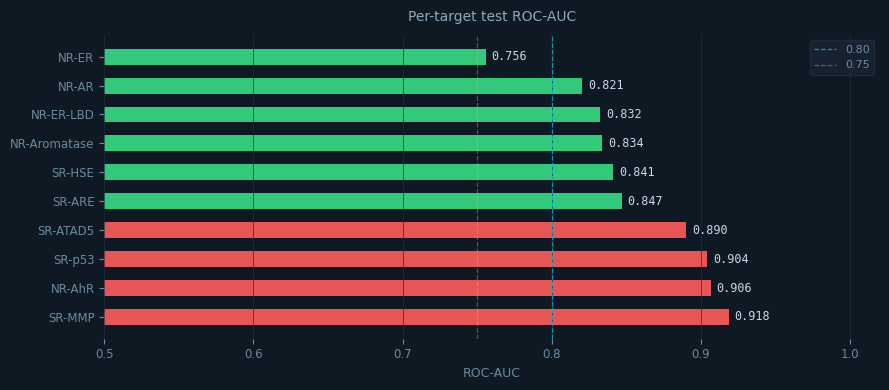

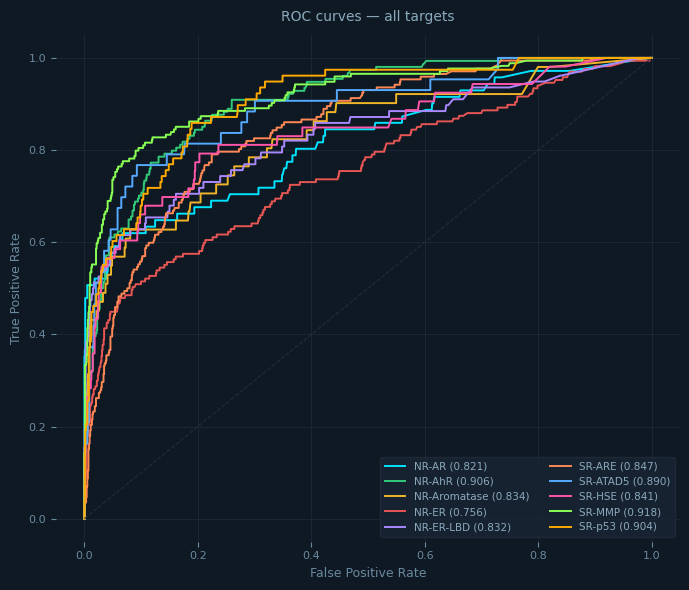


Saved:
  ensemble_NR_AR.pkl   (16.4 MB)
  ensemble_NR_AhR.pkl   (27.5 MB)
  ensemble_NR_Aromatase.pkl   (18.2 MB)
  ensemble_NR_ER.pkl   (38.2 MB)
  ensemble_NR_ER_LBD.pkl   (20.0 MB)
  ensemble_SR_ARE.pkl   (35.2 MB)
  ensemble_SR_ATAD5.pkl   (18.6 MB)
  ensemble_SR_HSE.pkl   (24.5 MB)
  ensemble_SR_MMP.pkl   (27.8 MB)
  ensemble_SR_p53.pkl   (23.9 MB)
  variance_threshold.pkl
  feature_columns.pkl
  targets.pkl
  results.csv

All models saved to saved_models/


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — Optuna Tuning + Ensemble Training + Results + Save                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
import optuna, joblib, os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import ExtraTreesClassifier, VotingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from imblearn.over_sampling import BorderlineSMOTE, SMOTE

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

TUNE_TARGET = 'NR-AhR'
t_start     = time.time()


# ── Resampling ─────────────────────────────────────────────────────────────────
def resample(X, y):
    """BorderlineSMOTE; falls back to SMOTE if neighbourhood too small."""
    pos = int(y.sum())
    if pos < 6:
        return X, y
    k = min(5, pos - 1)
    try:
        return BorderlineSMOTE(k_neighbors=k, random_state=42).fit_resample(X, y)
    except:
        return SMOTE(k_neighbors=k, random_state=42).fit_resample(X, y)


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  OPTUNA — LGB proxy with early stopping                                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
def objective(trial):
    X_tr, y_tr = get_target_data(TUNE_TARGET, train_idx)
    X_tr, y_tr = resample(X_tr.values, y_tr.values)

    params = dict(
        n_estimators      = 1000,           # high ceiling; early stopping controls actual depth
        num_leaves        = trial.suggest_int('nl',   20,  100),
        max_depth         = trial.suggest_int('d',    3,   8),
        learning_rate     = trial.suggest_float('lr', 0.01, 0.15, log=True),
        subsample         = trial.suggest_float('ss', 0.5,  0.95),
        colsample_bytree  = trial.suggest_float('cs', 0.4,  0.9),
        min_child_samples = trial.suggest_int('mcs',  5,   30),
        reg_alpha         = trial.suggest_float('ra',  1e-4, 10.0, log=True),
        reg_lambda        = trial.suggest_float('rl',  1e-4, 10.0, log=True),
        class_weight      = 'balanced',
        random_state      = 42,
        n_jobs            = 1,
        verbose           = -1,
    )

    cv     = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    for tr, val in cv.split(X_tr, y_tr):
        m = lgb.LGBMClassifier(**params)
        m.fit(
            X_tr[tr], y_tr[tr],
            eval_set=[(X_tr[val], y_tr[val])],
            eval_metric='auc',
            callbacks=[
                lgb.early_stopping(stopping_rounds=40, verbose=False),
                lgb.log_evaluation(-1),
            ],
        )
        scores.append(roc_auc_score(y_tr[val], m.predict_proba(X_tr[val])[:, 1]))
    return np.mean(scores)


print(f'Tuning on {TUNE_TARGET} — 30 trials (LGB proxy + early stopping)...')
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=30, show_progress_bar=True)
bp = study.best_params
print(f'Best CV AUC: {study.best_value:.4f}  '
      f'({(time.time()-t_start)/60:.1f} min elapsed)\n')


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  FINAL TRAINING — one ensemble per target                                    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
ET_PARAMS = dict(
    n_estimators = 300,
    max_depth    = None,   # grow full trees — ET is regularised by feature randomness
    max_features = 0.2,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1,
)

final_models = {}
results      = []

for target in TARGETS:
    t1 = time.time()
    X_tr, y_tr = get_target_data(target, train_idx)
    X_te, y_te = get_target_data(target, test_idx)

    if y_tr.sum() < 10:
        print(f'[SKIP] {target} — too few positives')
        continue

    # Per-target SMOTE + per-target imbalance weight
    X_rs, y_rs = resample(X_tr.values, y_tr.values)
    spw = (y_tr == 0).sum() / max(y_tr.sum(), 1)

    # Internal val split for early stopping only (20% of resampled train)
    # This is separate from the held-out test set — no data leakage
    n_val   = max(int(len(y_rs) * 0.2), 50)
    X_es    = X_rs[-n_val:]
    y_es    = y_rs[-n_val:]
    X_fit   = X_rs[:-n_val]
    y_fit   = y_rs[:-n_val]

    lgb_clf = lgb.LGBMClassifier(
        n_estimators      = 1000,
        num_leaves        = bp['nl'],
        max_depth         = bp['d'],
        learning_rate     = bp['lr'],
        subsample         = bp['ss'],
        colsample_bytree  = bp['cs'],
        min_child_samples = bp['mcs'],
        reg_alpha         = bp['ra'],
        reg_lambda        = bp['rl'],
        class_weight      = 'balanced',
        random_state      = 42,
        n_jobs            = -1,
        verbose           = -1,
    )
    lgb_clf.fit(
        X_fit, y_fit,
        eval_set=[(X_es, y_es)],
        eval_metric='auc',
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(-1),
        ],
    )

    xgb_clf = xgb.XGBClassifier(
        n_estimators         = 1000,
        max_depth            = bp['d'],
        learning_rate        = bp['lr'],
        subsample            = bp['ss'],
        colsample_bytree     = bp['cs'],
        min_child_weight     = max(1, bp['mcs'] // 5),
        reg_alpha            = bp['ra'],
        reg_lambda           = bp['rl'],
        scale_pos_weight     = spw,
        early_stopping_rounds= 50,
        eval_metric          = 'auc',
        use_label_encoder    = False,
        random_state         = 42,
        n_jobs               = -1,
        verbosity            = 0,
    )
    xgb_clf.fit(
        X_fit, y_fit,
        eval_set=[(X_es, y_es)],
        verbose=False,
    )

    et_clf = ExtraTreesClassifier(**ET_PARAMS)
    et_clf.fit(X_rs, y_rs)   # ET gets full resampled set — no early stopping needed

    clf = VotingClassifier(
        estimators=[('lgb', lgb_clf), ('xgb', xgb_clf), ('et', et_clf)],
        voting='soft',
        weights=[2, 2, 1],
        n_jobs=-1,
    )
    # VotingClassifier needs to be told estimators are already fitted
    clf.estimators_      = [lgb_clf, xgb_clf, et_clf]
    clf.le_              = None
    clf.classes_         = np.array([0, 1])
    clf.named_estimators_ = {'lgb': lgb_clf, 'xgb': xgb_clf, 'et': et_clf}

    probs = clf.predict_proba(X_te.values)[:, 1]
    auc   = roc_auc_score(y_te, probs)
    elapsed = time.time() - t1

    final_models[target] = clf
    results.append({
        'Target'          : target,
        'ROC-AUC'         : round(auc, 4),
        'Positives (train)': int(y_tr.sum()),
        'Imbalance'        : f'{spw:.1f}x',
        'LGB trees'        : lgb_clf.best_iteration_,
        'XGB trees'        : xgb_clf.best_iteration,
        'Time (s)'         : round(elapsed, 1),
    })
    print(f'{target:15s}  AUC={auc:.4f}  '
          f'imbalance={spw:.1f}x  '
          f'LGB={lgb_clf.best_iteration_}t  '
          f'XGB={xgb_clf.best_iteration}t  '
          f'({elapsed:.0f}s)')


# ── Results table ──────────────────────────────────────────────────────────────
df_results = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print('\n' + '='*65)
print(df_results[['Target','ROC-AUC','Imbalance','LGB trees','XGB trees']].to_string(index=False))
print(f'\nMean AUC : {df_results["ROC-AUC"].mean():.4f}')
print(f'Total time: {(time.time()-t_start)/60:.1f} min')


# ── AUC bar chart ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('#0f1923')
ax.set_facecolor('#0f1923')

colors = ['#e85555' if v >= 0.85 else '#33c97a' if v >= 0.75 else '#f0b429'
          for v in df_results['ROC-AUC']]
bars = ax.barh(df_results['Target'], df_results['ROC-AUC'],
               color=colors, height=0.55, edgecolor='none')
ax.axvline(0.80, color='#00e5ff', linestyle='--', linewidth=0.9, alpha=0.6, label='0.80')
ax.axvline(0.75, color='#f0b429', linestyle='--', linewidth=0.9, alpha=0.4, label='0.75')
ax.set_xlim(0.5, 1.02)
ax.set_xlabel('ROC-AUC', color='#6a8a9f', fontsize=9)
ax.set_title('Per-target test ROC-AUC', color='#8aaabb', fontsize=10, pad=10)
for bar, val in zip(bars, df_results['ROC-AUC']):
    ax.text(val + 0.004, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=8.5,
            color='#c8d8e8', fontfamily='monospace')
ax.tick_params(colors='#6a8a9f', labelsize=8.5)
for spine in ax.spines.values(): spine.set_visible(False)
ax.xaxis.grid(True, color='#1e2d3d', linewidth=0.5)
ax.legend(fontsize=8, labelcolor='#6a8a9f',
          facecolor='#1a2535', edgecolor='#1e2d3d')
plt.tight_layout()
plt.savefig('auc_results.png', dpi=150, bbox_inches='tight', facecolor='#0f1923')
plt.show()


# ── ROC curves (all targets on one plot) ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('#0f1923')
ax.set_facecolor('#0f1923')
palette = ['#00e5ff','#33c97a','#f0b429','#e85555','#aa88ff',
           '#ff8855','#55aaff','#ff55aa','#88ff55','#ffaa00']

for i, row in enumerate(results):
    t = row['Target']
    if t not in final_models: continue
    y_prob = final_models[t].predict_proba(get_target_data(t, test_idx)[0].values)[:, 1]
    y_true = get_target_data(t, test_idx)[1]
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ax.plot(fpr, tpr, color=palette[i % len(palette)],
            lw=1.4, label=f'{t} ({row["ROC-AUC"]:.3f})')

ax.plot([0,1],[0,1], '--', color='#1e2d3d', lw=0.8)
ax.set_xlabel('False Positive Rate', color='#6a8a9f', fontsize=9)
ax.set_ylabel('True Positive Rate',  color='#6a8a9f', fontsize=9)
ax.set_title('ROC curves — all targets', color='#8aaabb', fontsize=10, pad=10)
ax.tick_params(colors='#6a8a9f', labelsize=8)
for spine in ax.spines.values(): spine.set_visible(False)
ax.xaxis.grid(True, color='#1e2d3d', linewidth=0.5)
ax.yaxis.grid(True, color='#1e2d3d', linewidth=0.5)
ax.legend(fontsize=7.5, labelcolor='#8aaabb',
          facecolor='#1a2535', edgecolor='#1e2d3d',
          loc='lower right', ncol=2)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight', facecolor='#0f1923')
plt.show()


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  SAVE MODELS                                                                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
os.makedirs('saved_models', exist_ok=True)

# Individual target models
for target, clf in final_models.items():
    safe = target.replace('-', '_')
    joblib.dump(clf, f'saved_models/ensemble_{safe}.pkl')

# Shared inference artefacts (needed by server.py / Gradio cell)
joblib.dump(vt,                  'saved_models/variance_threshold.pkl')
joblib.dump(list(X_all.columns), 'saved_models/feature_columns.pkl')
joblib.dump(TARGETS,             'saved_models/targets.pkl')

# Results table
df_results.to_csv('saved_models/results.csv', index=False)

print('\nSaved:')
for target in final_models:
    size = os.path.getsize(f'saved_models/ensemble_{target.replace("-","_")}.pkl')
    print(f'  ensemble_{target.replace("-","_")}.pkl   ({size/1e6:.1f} MB)')
print(f'  variance_threshold.pkl')
print(f'  feature_columns.pkl')
print(f'  targets.pkl')
print(f'  results.csv')
print(f'\nAll models have been saved to saved_models/')